In [1]:
import yaml
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load nodes yaml
with open("../models/ASEAN/nodes.yaml", "r") as file:
    nodes = yaml.safe_load(file)['nodes']

# Load links yaml
with open("../models/ASEAN/links.yaml", "r") as file:
    links = yaml.safe_load(file)['links']

# Load time definitions yaml
with open("../models/ASEAN/time_definitions.yaml", "r") as file:
    time_definition = yaml.safe_load(file)['time_definition']

# Load generators yaml
with open("../models/ASEAN/generators.yaml", "r") as file:
    generators = yaml.safe_load(file)

# Load demand yaml
with open("../models/ASEAN/demand.yaml", "r") as file:
    demand = yaml.safe_load(file)['demand']

In [3]:
demand[0]['multiplier']

{'IDNJW': 1,
 'IDNKA': 1,
 'IDNML': 1,
 'IDNPP': 1,
 'IDNSL': 1,
 'IDNSM': 1,
 'IDNNU': 1,
 'KHMXX': 1,
 'MYSPE': 1,
 'MYSSK': 1,
 'MYSSH': 0.05,
 'PHLLU': 1,
 'PHLMI': 1,
 'PHLVI': 1,
 'SGPXX': 1,
 'THACE': 1,
 'THANO': 1,
 'THASO': 1,
 'VNMCE': 1,
 'VNMSO': 1,
 'VNMNO': 1,
 'BRNXX': 1,
 'LAOXX': 1}

In [4]:
network = pypsa.Network()

# ---
# set time index (snapshots)
year = time_definition['year']

snapshot = (
    pd.date_range(
        start=f'{year}-01-01 00:00:00', 
        end= f'{year}-01-31 23:00:00', 
        freq='h'
    )
)

network.set_snapshots(snapshot)

# ---
# add carriers

#emissions = {'coal': 0.34, 'gas': 0.2, 'oil': 0.26, 'hydro': 0}

network.madd(
    "Carrier",
    ["bioenergy", "coal", "diesel", "gas-ccgt", "gas-ocgt", "geothermal", "hydro", "oil", "solar-pv", "waste", "wind-offshore", "wind-onshore"],
    #co2_emissions=emissions,
    nice_name=["bioenergy", "coal", "diesel", "gas-ccgt", "gas-ocgt", "geothermal", "hydro", "oil", "solar-pv", "waste", "wind-offshore", "wind-onshore"],
    color=["teal", "black", "darkgrey", "grey", "gainsboro", "brown", "blue", "silver", "peru", "gold", "green", "cyan"],
)

# ---
# add buses (nodes)
for node in nodes:
    network.add(
        "Bus",  # PyPSA component
        node['id'], # bus name
        x = node['coords'][1], # longitude
        y = node['coords'][0] # latitude
    )

# ---
# add lines
for link in links:
    network.add(
        "Link", 
        name=link['id'],
        bus0=link['from_node'],
        bus1=link['to_node'],
        p_nom=link['initial_capacity'],
        p_nom_extendable=link['extendable'],
        carrier=link['carrier'],
        efficiency=1,
        lifetime=99,
    )

# ---
# add generators

for technology in generators:
    for bus in technology['initial_capacity'].keys():
        network.add(
            'Generator', # PyPSA component
            bus + '-' + technology['id'], # generator name
            type = technology['type'], # technology type (e.g., solar, gas-ccgt etc.)
            bus = bus, # region/bus/balancing zone
            # ---
            # unique technology parameters by bus
            p_nom = technology['initial_capacity'][bus], # starting capacity (MW)
            p_nom_extendable = technology['extendable'], # can the model build more?
            capital_cost = technology['capital_cost'], # currency/MW
            marginal_cost = technology['marginal_cost'], # currency/MWh
            # ---
            # universal technology parameters
            carrier = technology['carrier'], # commodity/carrier
            lifetime = technology['lifetime'], # years
            efficiency = technology['efficiency'], # efficiency
            start_up_cost = technology['start_up_cost'], # currency/MW
            shut_down_cost = technology['shut_down_cost'], # currency/MW
            ramp_limit_up = technology['ramp_limit_up'], # per unit
            ramp_limit_down = technology['ramp_limit_up'], # per unit
            #committable = technology['committable'], # for unit commitment
        )

# ---
# add load
demand_profiles = (
    pd
    .read_csv('../data/clean/demand_profiles.csv')
    .drop('hour',axis=1)
    .iloc[0:len(network.snapshots)]
)

for bus in demand_profiles.columns:
    network.add(
        "Load", # PyPSA component
        bus, # load name
        bus=bus, # region/bus/balancing zone
        p_set=demand[0]['multiplier'][bus] * demand_profiles[bus].values * 1000 # demand profile
    )

/Users/aman/miniconda3/envs/V20/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



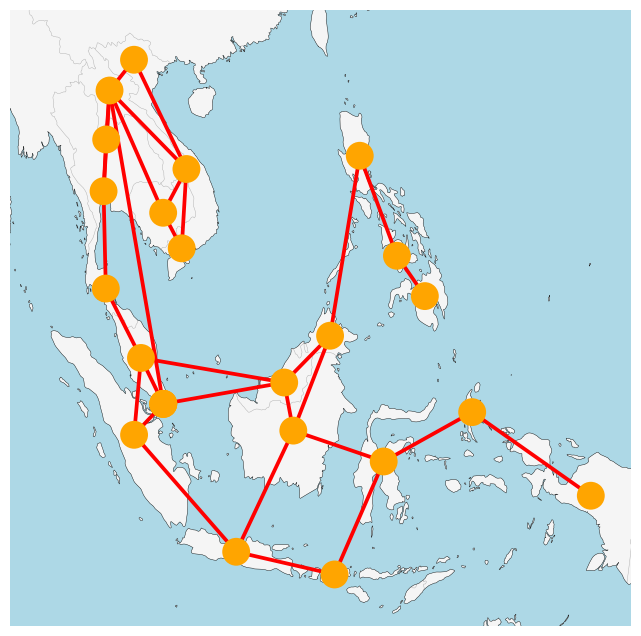

In [20]:
# ---
# plot
import cartopy.crs as ccrs

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=1,
    bus_colors='orange',
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=0.1,
    #flow=flow,
    line_widths=0,
    line_colors='red',
    link_widths=2.7,
    link_colors='red',
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    ax=ax,
)


In [6]:
network.optimize(solver_name='highs')

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 46.96it/s]
INFO:linopy.io: Writing time: 0.8s
INFO:linopy.solvers:Log file at /private/var/folders/jj/phtp57h948z6wfc9fbrdq9fr0000gp/T/highs.log.


Running HiGHS 1.5.3 [date: 2023-05-16, git hash: 594fa5a9d]
Copyright (c) 2023 HiGHS under MIT licence terms
Presolving model
127224 rows, 132580 cols, 374976 nonzeros
126480 rows, 131836 cols, 373488 nonzeros
Presolve : Reductions: rows 126480(-165352); columns 131836(-5245); elements 373488(-197344)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0384361300e+06 Pr: 14880(2.48491e+08) 0s
      54230     2.3316473017e+08 Pr: 26433(1.73818e+09); Du: 0(0.000191981) 5s
      74587     2.4776540826e+08 Pr: 26412(3.12573e+09); Du: 0(0.000206963) 10s
      77963     2.4776541140e+08 Pr: 26716(2.17025e+09); Du: 0(0.000200849) 16s
      83838     2.4776542005e+08 Pr: 27749(2.17487e+09); Du: 0(0.000196256) 21s
      86650     2.4776542320e+08 Pr: 27492(1.3189e+09); Du: 0(0.000195121) 26s
      90446     2.4776542847e+08 Pr: 31943(1.19766e+09); Du: 0(0.000194491) 31s
      94155     2.4776543462e+08 Pr: 2

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 137081 primals, 291832 duals
Objective: 2.48e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [7]:
network.objective 

247857344.8282855

In [8]:
(network.statistics.capex() + network.statistics.opex())

component  carrier      
Generator  bioenergy        2.994837e+07
           coal             3.135133e+07
           diesel           7.257507e+06
           gas-ccgt         1.560488e+07
           gas-ocgt         2.913230e+07
           geothermal       1.382309e+07
           hydro            3.765672e+07
           oil              2.538607e+07
           solar-pv         3.035807e+07
           waste            2.042723e+07
           wind-offshore    9.419621e+05
           wind-onshore     7.008261e+06
dtype: float64

In [9]:
network.generators.groupby(by=['bus','type']).sum(numeric_only=True)[['p_nom','p_nom_opt']]

attribute            p_nom    p_nom_opt
bus   type                             
BRNXX coal          220.00  5532.452282
      gas           547.99  8548.724448
IDNJW bioenergy      64.00   880.910666
      biomass       268.54   372.142752
      coal       310527.00   929.973072
...                    ...          ...
VNMSO gas          9646.00  3977.546386
      hydro        1167.40  1156.492749
      oil           501.00  1250.014751
      solar        4867.00  2037.751282
      wind         2637.00  3631.065603

[141 rows x 2 columns]

<Axes: xlabel='bus'>

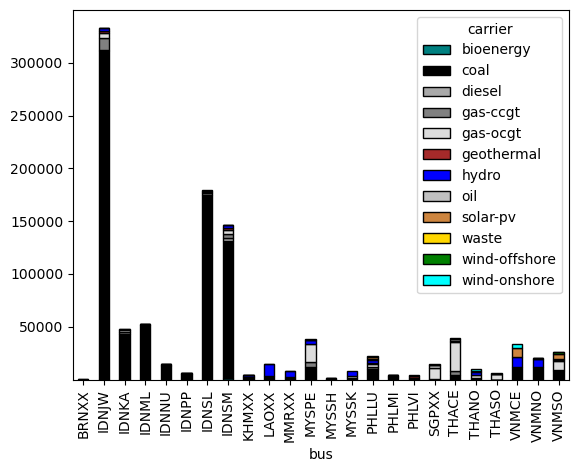

In [10]:
df = ( network
 .generators
 .groupby(['carrier','bus'])
 .sum(numeric_only=True)
 .p_nom
 #.div(1e3)
 .reset_index()
 .pivot_table(index='bus',columns='carrier',values='p_nom', aggfunc='sum')
)

df.plot(
    kind='bar', 
    stacked=True, 
    color=df.columns.map(network.carriers.color),
    edgecolor='black',
) 

<Axes: xlabel='snapshot', ylabel='MW'>

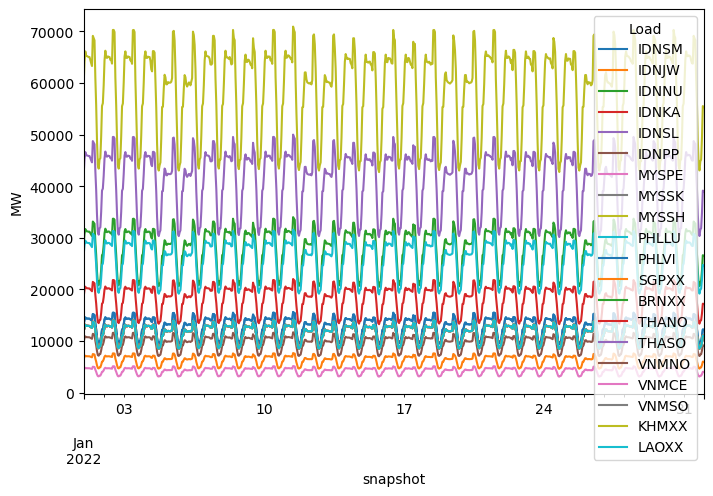

In [11]:
network.loads_t.p_set.plot(figsize=(8, 5), ylabel="MW")

/var/folders/jj/phtp57h948z6wfc9fbrdq9fr0000gp/T/ipykernel_29761/1761998587.py:2: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



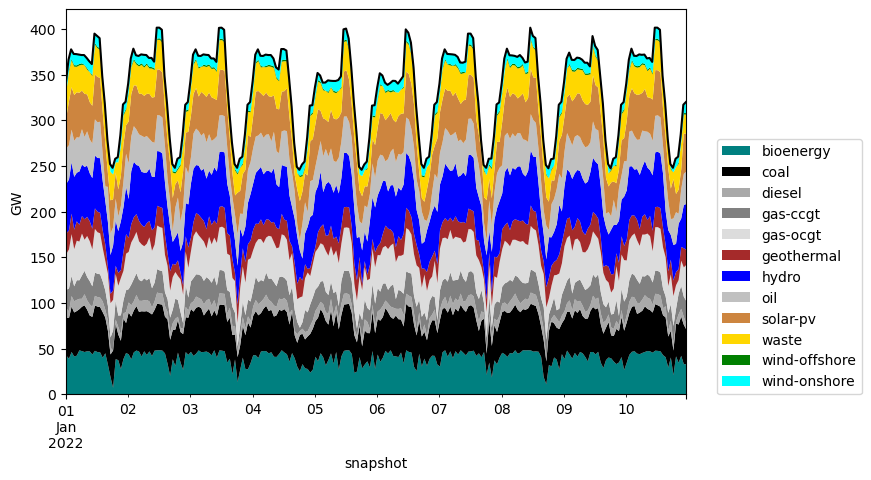

In [12]:
def plot_dispatch(n, time="2022-01"):
    p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().div(1e3)

    if not n.storage_units.empty:
        sto = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(8,5))

    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier > 0).iloc[0:24*10].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )

    charge = p_by_carrier.where(p_by_carrier < 0).dropna(how="all", axis=1).loc[time]

    if not charge.empty:
        charge.plot.area(
            ax=ax,
            linewidth=0,
            #color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).iloc[0:24*10].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    #ax.set_ylim(-200, 200)

plot_dispatch(network)

/Users/aman/miniconda3/envs/V20/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



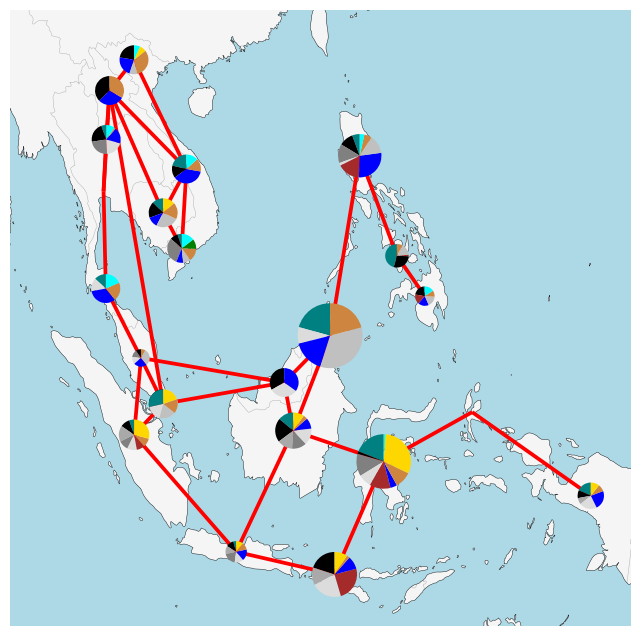

In [13]:
# ---
# plot
import cartopy.crs as ccrs

s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.carrier]).sum()
flow = pd.Series(10, index=network.branches().index)

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=s / 8e6,
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=0.1,
    #flow=flow,
    line_widths=0,
    link_widths=2.7,
    link_colors='red',
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    line_colors=network.lines_t.p0.mean().abs(),
    ax=ax,
)

#plt.colorbar(collection[2], fraction=0.04, pad=0.004, label="Flow in MW")
plt.show()

In [14]:
s

bus    carrier      
BRNXX  coal             3.273677e+06
       gas-ocgt         5.393188e+06
IDNJW  bioenergy        2.093948e+05
       coal             5.517385e+05
       diesel           5.758063e+05
                            ...     
VNMSO  hydro            6.516992e+05
       oil              7.351290e+05
       solar-pv         1.248431e+06
       wind-offshore    9.403688e+05
       wind-onshore     1.258273e+06
Length: 153, dtype: float64

In [15]:
s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.type]).sum()

In [16]:
network.generators['p_nom_opt'].reset_index()

,Generator,p_nom_opt
0,IDNJW-bioenergy,372.142752
1,IDNKA-bioenergy,3252.869979
2,IDNML-bioenergy,-0.000000
3,IDNPP-bioenergy,2088.200231
4,IDNSL-bioenergy,9272.894385
...,...,...
148,THANO-wind-onshore,1479.717612
149,THASO-wind-onshore,2561.625860
150,VNMCE-wind-onshore,1909.260598
151,VNMNO-wind-onshore,1054.515820


In [17]:
network.links_t.p0.resample('ME').sum()

Link,BRNXX-MYSSK,IDNJW-IDNKA,IDNJW-IDNNU,IDNJW-IDNSM,IDNKA-IDNSL,IDNKA-MYSSH,IDNKA-MYSSK,IDNML-IDNPP,IDNML-IDNSL,IDNNU-IDNSL,...,KHMXX-VNMSO,PHLLU-PHLVI,PHLMI-PHLVI,VNMCE-VNMNO,VNMCE-VNMSO,THANO-THACE,THACE-THASO,THASO-MYSPE,THANO-LAOXX,THACE-LAOXX
snapshot,,,,,,,,,,,,,,,,,,,,,
2022-01-31,28676.86512,411.128528,0.0,0.0,0.0,3253.459641,11207.390489,0.0,0.0,4515.49437,...,615.556542,0.0,3.908040e+06,880.533282,1195.299719,325.954972,325.954972,1376.644295,6620.017751,0.0


In [18]:
network.links_t.p1.resample('ME').sum()

Link,BRNXX-MYSSK,IDNJW-IDNKA,IDNJW-IDNNU,IDNJW-IDNSM,IDNKA-IDNSL,IDNKA-MYSSH,IDNKA-MYSSK,IDNML-IDNPP,IDNML-IDNSL,IDNNU-IDNSL,...,KHMXX-VNMSO,PHLLU-PHLVI,PHLMI-PHLVI,VNMCE-VNMNO,VNMCE-VNMSO,THANO-THACE,THACE-THASO,THASO-MYSPE,THANO-LAOXX,THACE-LAOXX
snapshot,,,,,,,,,,,,,,,,,,,,,
2022-01-31,-28676.86512,-411.128528,0.0,0.0,0.0,-3253.459641,-11207.390489,0.0,0.0,-4515.49437,...,-615.556542,0.0,-3.908040e+06,-880.533282,-1195.299719,-325.954972,-325.954972,-1376.644295,-6620.017751,0.0


In [19]:
# asean_country_iso = ['IDN', 'MYS', 'PHL', 'SGP', 'THA', 'VNM', 'BRN', 'KHM', 'LAO', 'MMR']

# df = ( pd
#  .read_csv('../data/clean/ember-electricity-data.csv', sep=',')
# )

# ( df
#  .loc[ df['Country code'].isin(asean_country_iso)]
#  .query('Year == 2022')
#  .query('Category == "Capacity"')
#  .query('Subcategory == "Fuel"')
#  .pivot_table(index='Country code', columns='Variable', values='Value', aggfunc='sum')
#  .mul(1000)
# )